In [ ]:
import os
# import json

import numpy as np
# import pandas as pd
import scipy.ndimage as ndi

from scipy.ndimage import binary_closing, binary_dilation
from skimage.morphology import ball

from utils import (
    get_vesselness,
    load_vesselness_cache,
    save_vesselness_cache,
    # get_vesselness_optimized,
    plot_mip_projection,
    visualize_aorta_with_ostia,
    run_core_preprocessing_pipeline,
    find_ostia,
    region_growing_segmentation,
    load_raw_img_and_label,
    dice_score,
    check_ostium_intersection,
    visualize_3d_k3d,
    # region_growing_article,
    downscale_image
)

# Segmentar Artéria via Crescimento de Região

## Carregar dados

In [2]:
# Carregar a imagem NIfTI
LOAD_CACHE = True
IMG_ID = 640 #[1, 2, 3, 4, 134, 195, 401, 487, 491, 548, 649]
base_path  = '/media/matheus/HD/DatasetsCCTA/ImageCAS'
base_save_path = '/media/matheus/HD/DatasetsCCTA/Processed_ImageCAS'
nii_img, nii_label = load_raw_img_and_label(f'{base_path}/{IMG_ID}.img.nii.gz', f'{base_path}/{IMG_ID}.label.nii.gz')

spacing = nii_img.header.get_zooms()  # (dx, dy, dz)
img = np.array(nii_img.get_fdata())
label = np.array(nii_label.get_fdata()).astype(np.uint8)

# Pré-processamento
downscale_factors = (2, 2, 1)  # Fatores de escala
down_image, thresh_image, lcc_image, thresh_vals = run_core_preprocessing_pipeline(
    img,
    downscale_factors=downscale_factors,
    lcc_per_slice=True
)

label = downscale_image(label, downscale_factors, order=0)

# Calcular o novo espaçamento após downscale
dx, dy, dz = spacing[0] * downscale_factors[0], spacing[1] * downscale_factors[1], spacing[2] * downscale_factors[2]

# Visualização da imagem pré-processada
vmin, vmax = lcc_image.min(), lcc_image.max()

# Carregar mask segmentada como npy
mask_path = f"{base_save_path}/segmented_aorta/{IMG_ID}_mask_aorta.npy"
aorta_mask = np.load(mask_path).astype(np.uint8)

print(f"Máscara carregada: {aorta_mask.shape}")
print(f"Valores únicos na máscara: {np.unique(aorta_mask)}\n")
print(f"Shape da máscara da aorta: {aorta_mask.shape}\n")

affine_downscaled = nii_img.affine.copy()
affine_downscaled[0, 0] /= downscale_factors[0]
affine_downscaled[1, 1] /= downscale_factors[1]
affine_downscaled[2, 2] /= downscale_factors[2]

print(f"IMG_ID: {IMG_ID}")
print(f"Spacing: {spacing}")
print(f"Shape da imagem: {lcc_image.shape}")
print(f"Min e Max da imagem: {lcc_image.min()}, {lcc_image.max()}\n")

Máscara carregada: (256, 256, 275)
Valores únicos na máscara: [0 1]

Shape da máscara da aorta: (256, 256, 275)

IMG_ID: 640
Spacing: (np.float32(0.36132812), np.float32(0.36132812), np.float32(0.5))
Shape da imagem: (256, 256, 275)
Min e Max da imagem: -300.0, 521.9984778669717



## Mapa de Vesselness

Vesselness carregado do cache.
Shape Vesselness: (256, 256, 275)
Vesselness min: 0.0, max: 0.7074093891101465
Mean: 0.0017330812899051852, std: 0.012563886180174667


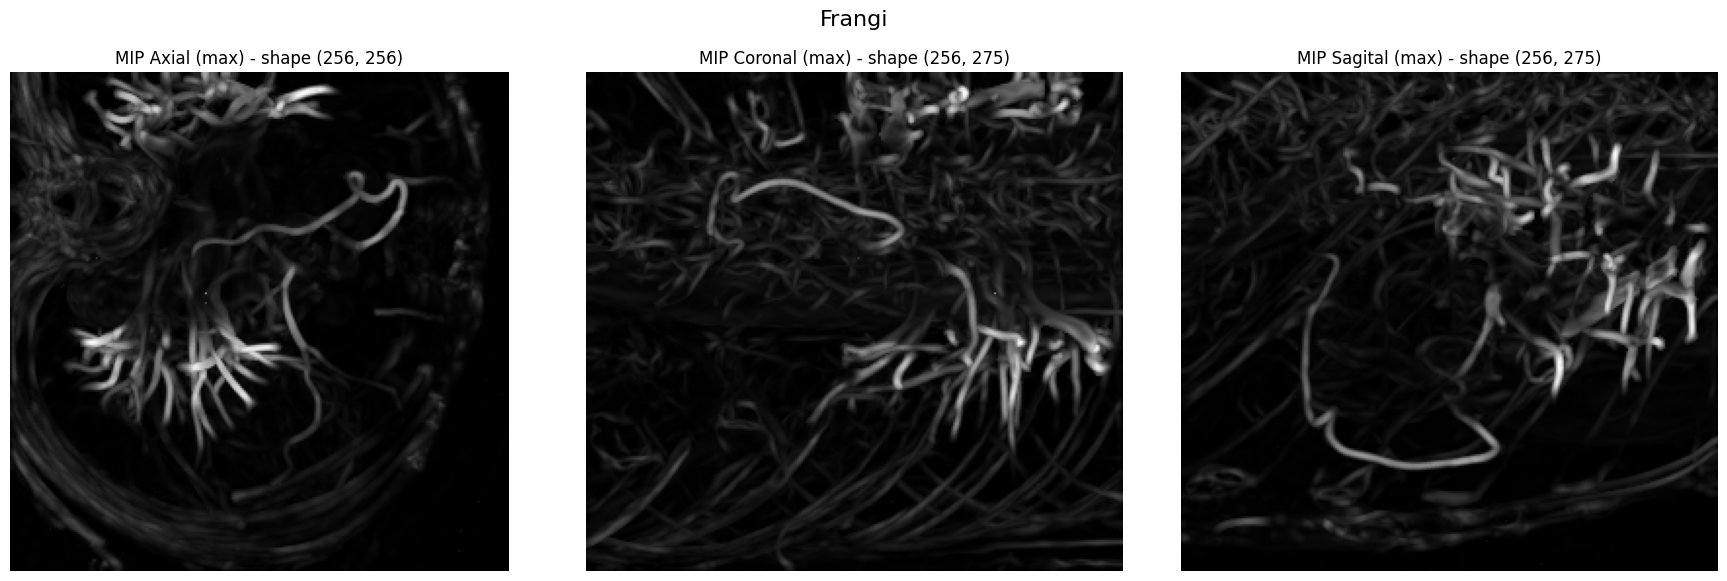

In [3]:
cache = load_vesselness_cache(IMG_ID, cache_dir=f'{base_save_path}/vesselness_cache')
vesselness_i = None

if cache is not None and LOAD_CACHE:
    vesselness_i = cache
    print("Vesselness carregado do cache.")
else:
    vesselness_i = get_vesselness(lcc_image, sigmas=np.arange(2.5, 3.5, 1), black_ridges=False,
                                  alpha=0.5, # controla a distinção entre uma estrutura Tubular (artéria) e uma estrutura Plana
                                  beta=1, # controla a distinção entre um Tubo (comprido) e uma Bola (redonda/blob)
                                  gamma=30, # controla a sensibilidade ao Contraste/Intensidade. Ele distingue entre Estrutura Real e Ruído de Fundo
                                  normalization="none")
    #vesselness_i = get_vesselness_optimized(lcc_image, sigmas=np.arange(2.5, 3.5, 0.5), alpha=0.5, beta=0.5)
    save_vesselness_cache(vesselness_i, IMG_ID, cache_dir=f'{base_save_path}/vesselness_cache')
    print("✓ Vesselness calculado e salvo no cache!")

# Plotar as imagens
print(f"Shape Vesselness: {vesselness_i.shape}")
print(f"Vesselness min: {vesselness_i.min()}, max: {vesselness_i.max()}")
print(f"Mean: {vesselness_i.mean()}, std: {vesselness_i.std()}")
plot_mip_projection(vesselness_i, title='Frangi', cmap='gray')

## Verificar mapa de vasos

In [4]:
truth_mask = np.logical_and(label, vesselness_i > 0)

plot = visualize_3d_k3d(
    truth_mask,
    spacing=(dx, dy, dz),
    color=0xff0000,  # Vermelho
    opacity=0.7
)

Gerando mesh 3D...


Output()

In [5]:
cache = load_vesselness_cache(IMG_ID, cache_dir=f'{base_save_path}/vesselness_cache2')

if cache is not None and LOAD_CACHE:
    vesselness_ii = cache
    print("Vesselness II carregado do cache.")
else:
    vesselness_ii = get_vesselness(lcc_image, sigmas=np.arange(1.5, 2.5, 0.5), black_ridges=False,
                                   alpha=0.5, # controla a distinção entre uma estrutura Tubular (artéria) e uma estrutura Plana
                                   beta=0.5, # controla a distinção entre um Tubo (comprido) e uma Bola (redonda/blob)
                                   gamma=55, # controla a sensibilidade ao Contraste/Intensidade. Ele distingue entre Estrutura Real e Ruído de Fundo
                                   normalization="none")
    save_vesselness_cache(vesselness_ii, IMG_ID, cache_dir=f'{base_save_path}/vesselness_cache2')
    print("✓ Vesselness II calculado e salvo no cache!")

print(f"Shape Vesselness II: {vesselness_ii.shape}")
print(f"Vesselness II min: {vesselness_ii.min()}, max: {vesselness_ii.max()}")
print(f"Mean: {vesselness_ii.mean()}, std: {vesselness_ii.std()}")

truth_mask = np.logical_and(label, vesselness_ii > 0)

plot = visualize_3d_k3d(
    truth_mask,
    spacing=(dx, dy, dz),
    color=0xff0000,  # Vermelho
    opacity=0.7
)

Vesselness II carregado do cache.
Shape Vesselness II: (256, 256, 275)
Vesselness II min: 0.0, max: 0.8302645675345423
Mean: 0.0023659386551918905, std: 0.017426811676988823
Gerando mesh 3D...


Output()

## Encontrar os óstios

In [6]:
# Encontrar os óstios
ostia_left, ostia_right = find_ostia(
    aorta_mask,
    vesselness_i,
    top_n=2000,
    max_z_diff=52,
    lower_fraction=0.80,      # 80% inferior da aorta (padrão)
    min_center_distance_factor=0.70,   # 70% do diâmetro mínimo (padrão)
    min_lateral_factor=0.50,  # 50% da distância mínima entre centros
    erosion_radius=4
)

y_l, x_l, z_l = ostia_left
y_r, x_r, z_r = ostia_right

print(f"Coordenadas do óstio esquerdo: (x: {x_l}, y: {y_l}, z: {z_l})")
print(f"Coordenadas do óstio direito: (x: {x_r}, y: {y_r}, z: {z_r})")

Coordenadas do óstio esquerdo: (x: 178, y: 89, z: 146)
Coordenadas do óstio direito: (x: 144, y: 101, z: 188)


In [7]:
# Uso:
label_artery = (label == 1).astype(np.uint8)

left_info = check_ostium_intersection(
    ostia_left,
    label_artery,
    spacing=(dy, dx, dz),
    ostium_name="Óstio esquerdo",
    distance_threshold_mm=7.0
)

right_info = check_ostium_intersection(
    ostia_right,
    label_artery,
    spacing=(dy, dx, dz),
    ostium_name="Óstio direito",
    distance_threshold_mm=7.0
)

if left_info['intersects']:
    print("✓ Óstio esquerdo intersecta o label")
else:
    print(f"✗ Óstio esquerdo NÃO intersecta")
    print(f"  Distância euclidiana: {left_info['euclidean_dist']:.2f} voxels")
    print(f"  Distância física: {left_info['physical_dist']:.2f} mm")

if right_info['intersects']:
    print("✓ Óstio direito intersecta o label")
else:
    print(f"✗ Óstio direito NÃO intersecta")
    print(f"  Distância euclidiana: {right_info['euclidean_dist']:.2f} voxels")
    print(f"  Distância física: {right_info['physical_dist']:.2f} mm")

# Verificar se ambos intersectam
if left_info['intersects'] and right_info['intersects']:
    print("\n✓ Ambos os óstios estão corretos!")
else:
    total_dist_voxels = left_info['euclidean_dist'] + right_info['euclidean_dist']
    total_dist_mm = left_info['physical_dist'] + right_info['physical_dist']
    print(f"\n⚠ Distância total dos óstios:")
    print(f"  {total_dist_voxels:.2f} voxels ({total_dist_mm:.2f} mm)")

✗ Óstio esquerdo NÃO intersecta
  Distância euclidiana: 1.41 voxels
  Distância física: 0.88 mm
✗ Óstio direito NÃO intersecta
  Distância euclidiana: 1.00 voxels
  Distância física: 0.50 mm

⚠ Distância total dos óstios:
  2.41 voxels (1.38 mm)


In [8]:
plot = visualize_aorta_with_ostia(
    aorta_mask,
    ostia_left,
    ostia_right,
    spacing=(dy, dx, dz),
    label_mask=label_artery,
    use_physical_coords=True  # pixels
)

html_path = f'../output/segmented_ostios/{IMG_ID}_aorta_ostia.html'

if not os.path.exists('../output/segmented_ostios/'):
    os.makedirs('../output/segmented_ostios/')
with open(html_path, 'w') as f:
    f.write(plot.get_snapshot())

print(f"✓ Plot salvo em: {html_path}")

Output()

✓ Plot salvo em: ../output/segmented_ostios/640_aorta_ostia.html


## Segmentar artéria via crescimento de região

In [9]:
region_growing_params = {
    "threshold": (vesselness_ii.max() - vesselness_ii.min()) / 5,
    "max_volume": 100000,
    "min_vesselness": vesselness_ii.max() * 0.078,
    "relaxed_floor_factor": 0.97,
    "switch_at_voxels": 2000,
    "comparison_window": 1,
    "smooth_relaxation": True,
    "verbose": False,
}


print(f"Threshold utilizado na segmentação por region growing: {region_growing_params['threshold']}\n")

left_mask = region_growing_segmentation(
    vesselness_ii,
    seed_point=ostia_left,  # (y, x, z)
    **region_growing_params
)

right_mask = region_growing_segmentation(
    vesselness_ii,
    seed_point=ostia_right,  # (y, x, z)
    **region_growing_params
)

""" left_mask = region_growing_article(
    vesselness_ii,
    seeds=[ostia_left],  # (y, x, z)
    threshold=threshold,
    max_volume=100000,
    min_vesselness=min_vesselness,
)

right_mask = region_growing_article(
    vesselness_ii,
        seeds=[ostia_right],  # (y, x, z)
    threshold=threshold,
    max_volume=100000,
    min_vesselness=min_vesselness
) """

# Todo: Verifica o peso de cada parâmetro, qnts voxels são afetados com a mudança

mesh_artery_mask = left_mask + right_mask

print("=" * 70)
print(f"Segmentação concluída: {np.sum(mesh_artery_mask):,} voxels totais")
print("=" * 70)

# 1. Fechamento: preencher buracos e conectar regiões
closing_radius = 3  # Conservador para não conectar vasos diferentes
closed_mask = binary_closing(mesh_artery_mask > 0, structure=ball(closing_radius)).astype(np.uint8)

# 2. Dilatação leve: compensar subestimação da largura
dilation_radius = 2  # Ajustar baseado no spacing físico
dilated_mask = binary_dilation(closed_mask, structure=ball(dilation_radius)).astype(np.uint8)

print("=" * 70)
print(f"Segmentação original:  {np.sum(mesh_artery_mask):>8,} voxels")
print(f"Após fechamento:       {np.sum(closed_mask):>8,} voxels (+{np.sum(closed_mask)-np.sum(mesh_artery_mask):,})")
print(f"Após dilatação final:  {np.sum(dilated_mask):>8,} voxels (+{np.sum(dilated_mask)-np.sum(mesh_artery_mask):,})")
print("=" * 70)

mesh_artery_mask = dilated_mask

plot = visualize_aorta_with_ostia(
    mesh_artery_mask,
    ostia_left,
    ostia_right,
    spacing=(dy, dx, dz),
    label_mask=label_artery,
    use_physical_coords=True,
)


Threshold utilizado na segmentação por region growing: 0.16605291350690846

Segmentação concluída: 9,372 voxels totais
Segmentação original:     9,372 voxels
Após fechamento:          9,747 voxels (+375)
Após dilatação final:    35,906 voxels (+26,534)


Output()

## Avaliar Segmentação - Dice Score

In [10]:
# Avaliar segmentação com Dice Score
label_coronary = (label == 1).astype(np.uint8)
dice_total = dice_score(mesh_artery_mask, label_coronary)

print("=" * 50)
print(f"Dice Score: {dice_total:.4f}")
print("=" * 50)
print(f"Voxels Preditos:     {np.sum(mesh_artery_mask):>8,}")
print(f"Voxels Ground Truth: {np.sum(label_coronary):>8,}")
print(f"Interseção:          {np.sum((mesh_artery_mask > 0) & label_coronary):>8,}")
print("=" * 50)

Dice Score: 0.7436
Voxels Preditos:       35,906
Voxels Ground Truth:   33,203
Interseção:            25,695
